In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
DATA_PATH = Path("../data/raw/dataset-tickets-multi-lang-4-20k.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


In [3]:
df.shape

(20000, 15)

In [4]:
df.columns.tolist()

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [5]:
df["language"].value_counts()

language
en    11923
de     8077
Name: count, dtype: int64

In [9]:
df_en = df[df["language"] == "en"].copy()

df_en.shape

(11923, 15)

In [10]:
df_en["queue"].value_counts()

queue
Technical Support                  3412
Product Support                    2232
Customer Service                   1859
IT Support                         1391
Billing and Payments               1302
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64

In [11]:
df_en[["subject", "body", "queue"]].isna().sum()

subject    1032
body          1
queue         0
dtype: int64

In [12]:
df_en = df_en.dropna(subset=["body"]).copy()

df_en["subject"] = df_en["subject"].fillna("")

df_en["text"] = (
    df_en["subject"].str.strip()
    + " "
    + df_en["body"].str.strip()
).str.strip()

df_en[["subject", "body", "text", "queue"]].head()

,subject,body,text,queue
1,Customer Support Inquiry,Seeking information on digital strategies that...,Customer Support Inquiry Seeking information o...,Customer Service
2,Data Analytics for Investment,I am contacting you to request information on ...,Data Analytics for Investment I am contacting ...,Customer Service
4,Security,"Dear Customer Support, I am reaching out to in...","Security Dear Customer Support, I am reaching ...",Customer Service
5,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Concerns About Securing Medical Data on 2-in-1...,Technical Support
7,Problem with Integration,"The integration stopped working unexpectedly, ...",Problem with Integration The integration stopp...,IT Support


In [13]:
print("Размер данных", df_en.shape)

print("Полные дубликаты", df_en.duplicated().sum())

print("Одинаковый текст и категории", df_en.duplicated(subset=["text", "queue"]).sum())

print("Одинаковый текст", df_en.duplicated(subset=["text"]).sum())

Размер данных (11922, 16)
Полные дубликаты 0
Одинаковый текст и категории 0
Одинаковый текст 0


In [15]:
df_en["text_length"] = df_en["text"].str.len()

df_en["text_length"].describe()

count    11922.000000
mean       416.762624
std        232.097664
min          4.000000
25%        232.000000
50%        387.000000
75%        572.000000
max       1825.000000
Name: text_length, dtype: float64

In [16]:
df_en.nsmallest(5, "text_length")[["text", "queue", "text_length"]]

,text,queue,text_length
549,Help,Billing and Payments,4
4145,Support needed,Billing and Payments,14
485,Hello support team,Customer Service,18
12193,Can you assist me?,Billing and Payments,18
6284,Seek assistance with billing,Billing and Payments,28


In [18]:
df_en.nlargest(5, "text_length")[["text", "queue", "text_length"]]

,text,queue,text_length
16604,Problem with Inaccurate Invoice Dear Customer ...,Billing and Payments,1825
4553,Refresh Digital Marketing Strategy for Enhance...,Product Support,1809
532,Support for Integrating Firebase on macOS Hell...,Customer Service,1714
6516,"Dear Customer Support, <br><br>I am contacting...",Product Support,1702
2622,Inquiry About Analytics Tools for QuickBooks O...,Customer Service,1677


In [19]:
df_en["word_count"] = df_en["text"].str.split().str.len()

df_en["word_count"].describe()

count    11922.000000
mean        62.725130
std         36.437055
min          1.000000
25%         34.000000
50%         58.000000
75%         87.000000
max        276.000000
Name: word_count, dtype: float64

In [24]:
print("Меньше 3 слов -", (df_en["word_count"] < 3).sum())
print("Меньше 5 слов -", (df_en["word_count"] < 5).sum())
print("Меньше 10 слов -", (df_en["word_count"] < 10).sum())

Меньше 3 слов - 3
Меньше 5 слов - 7
Меньше 10 слов - 132


In [27]:
queue_distribution = pd.DataFrame({
    "count": df_en["queue"].value_counts(),
    "shape_percent": (
        df_en["queue"].value_counts(normalize=True) * 100
    ).round(1),
})

queue_distribution

,count,shape_percent
queue,,
Technical Support,3412,28.6
Product Support,2231,18.7
Customer Service,1859,15.6
IT Support,1391,11.7
Billing and Payments,1302,10.9
Returns and Exchanges,582,4.9
Service Outages and Maintenance,442,3.7
Sales and Pre-Sales,330,2.8
Human Resources,205,1.7


TypeError: 'module' object is not callable

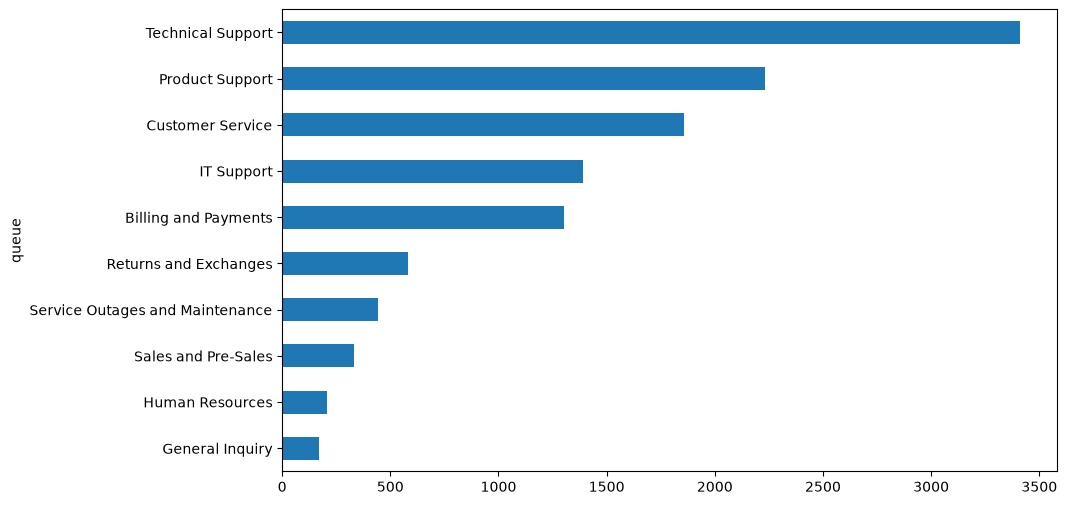

In [ ]:
df_en["queue"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(10, 6),
)
plt.
plt.title("Distribution of support ticket categories")
plt.xlabel("Number of tickets")
plt.ylabel("Queue")
plt.tight_layout()
plt.show()

In [30]:
PROCESSED_PATH = Path("../data/processed/tickets_en.csv")

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

df_model = df_en[["text", "queue"]].copy()
df_model.to_csv(PROCESSED_PATH, index=False)

df_model.shape

(11922, 2)